In [2]:
# Emotion Detection

In [3]:
import pandas as pd
import re
import gdown

google_drive_link = "https://drive.google.com/file/d/12iVo49pHF7T_tiQRzcF_PDAYCN1rcLLi/view?usp=drive_link"
file_id = re.search(r"/d/(\w+)/", google_drive_link).group(1)

# Define the output file name
output_file = 'fer2013.csv'

# Download the file
gdown.download(f'https://drive.google.com/uc?id={file_id}', output_file, quiet=False)

# Load the dataset into a Pandas DataFrame
data = pd.read_csv(output_file)

Downloading...
From (original): https://drive.google.com/uc?id=12iVo49pHF7T_tiQRzcF_PDAYCN1rcLLi
From (redirected): https://drive.google.com/uc?id=12iVo49pHF7T_tiQRzcF_PDAYCN1rcLLi&confirm=t&uuid=f000c680-13b0-4539-96f6-9d2ffbd65a75
To: /content/fer2013.csv
100%|██████████| 301M/301M [00:04<00:00, 72.9MB/s]


In [4]:
data.head()

,emotion,Usage,pixels
0,0,Training,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,Training,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,Training,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,Training,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,Training,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   emotion  35887 non-null  int64 
 1   Usage    35887 non-null  object
 2   pixels   35887 non-null  object
dtypes: int64(1), object(2)
memory usage: 841.2+ KB


In [6]:
data['emotion'].value_counts().sort_index()

,count
emotion,
0,4953
1,547
2,5121
3,8989
4,6077
5,4002
6,6198


In [7]:
data["Usage"].value_counts()

,count
Usage,
Training,28709
PublicTest,3589
PrivateTest,3589


### Data Preparation

In [8]:
emotions={0:"Angry",1:"Disgust",2:"Fear",3:"Happy",4:"Sad",5:"Surprise",6:"Neutral"} # Creating dictionary

In [9]:
import numpy as np
def prepare_data(data):
  image_array = np.zeros(shape=(len(data), 48, 48))
  image_label = np.array(list(map(int, data['emotion'])))

  for i,row in enumerate(data.index):
    image = np.fromstring(data.loc[row, 'pixels'], dtype=int, sep=" ")
    image = np.reshape(image, (48, 48))
    image_array[i] = image
  return image_array, image_label

In [10]:
# Using the prepare_data function defined
train_image_array, train_image_label = prepare_data(data[data['Usage']=='Training'])
val_image_array, val_image_label = prepare_data(data[data['Usage']=='PrivateTest'])
test_image_array, test_image_label = prepare_data(data[data['Usage']=='PublicTest'])

### Reshaping and Image scaling

In [11]:
# Reshaping the image arrays
train_images=train_image_array.reshape(train_image_array.shape[0],48,48,1) # starting from 0, x and y array, and one image at a time
val_images=val_image_array.reshape(val_image_array.shape[0],48,48,1)
test_images=test_image_array.reshape(test_image_array.shape[0],48,48,1)

# Data type conversion and normalization
# Convert pixel values to floating point numbers
train_images=train_images.astype('float32')/255
val_images=val_images.astype('float32')/255
test_images=test_images.astype('float32')/255

In [12]:
#OneHotEncode the emotion labels
from keras.utils import to_categorical
#onehotencode the labels
train_labels=to_categorical(train_image_label,num_classes=7)  # the seven emotions
val_labels=to_categorical(val_image_label,num_classes=7)
test_labels=to_categorical(test_image_label,num_classes=7)

In [13]:
# Calculating the class weigths for handling imbalanced data in training dataset
# Model should train even on less existing emotions
class_weight=dict(zip(range(0,7),
                      (((data[data["Usage"]=="Training"]["emotion"].value_counts()).sort_index())/
                       len(data[data["Usage"]=="Training"]["emotion"])).tolist()
))
print(class_weight)


{0: 0.1391549688251071, 1: 0.01518687519593159, 2: 0.14270786164617366, 3: 0.2513149186666202, 4: 0.16823992476226968, 5: 0.11045316799609878, 6: 0.17294228290779895}


In [14]:
# Data Visualization
import matplotlib.pyplot as plt
def plot_all_emotions():
  # Create the sub plot with 1 row and 7cols, defining the layout of the plot
  fig, axs=plt.subplots(1,7,figsize=(30,12))
  fig.subplots_adjust(hspace=.2,wspace=.2)
  axs=axs.ravel()   # flatten the data
  for i in range(7):
    #find the index of the first image with the corresponding emotion label(i)
    idx=data[data["emotion"]==i].index[0]
    # Plot each image
    axs[i].imshow(train_images[idx][:,:,0],cmap="gray")
    axs[i].set_title(emotions[train_labels[idx].argmax()])
    axs[i].set_xticklabels([])  # hides x labels
    axs[i].set_yticklabels([])  # hides y labels



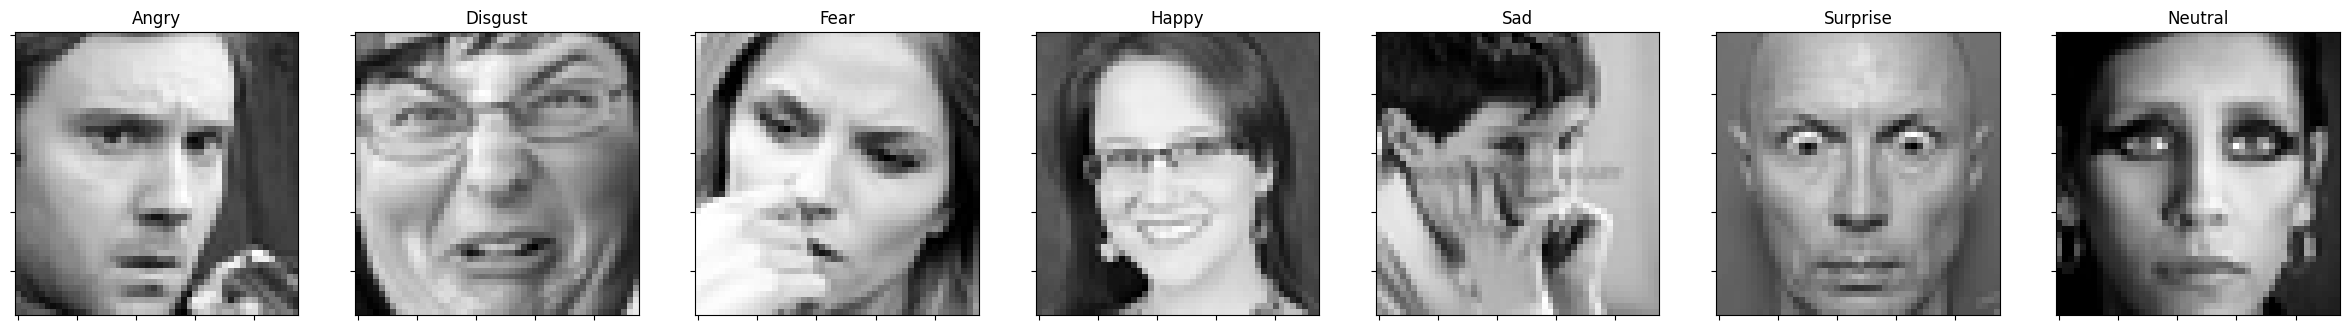

In [15]:
plot_all_emotions()

In [16]:
# Gender detection is the other project for info purposes
# Eg. airports for security
# Eg. Rehab centers
# Employee satisfaction levels from stress or disgust

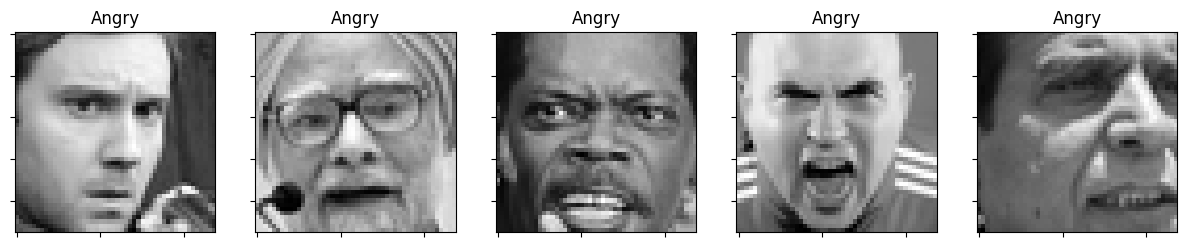

In [17]:
# Plot example images for specified emotion labels
# Parameters :

# Emotion label: The emotion label (0-6) for which to display example image
def plot_emotion(emotion_label):
  fig, axs=plt.subplots(1,5,figsize=(15,10))
  fig.subplots_adjust(hspace=.2,wspace=.2)  # horizontal space and width space adjusts space within subplot
  axs=axs.ravel()   # flatten the array
  for i in range(5):
    idx=data[data["emotion"]==emotion_label].index[i]

    # display the image
    axs[i].imshow(train_images[idx][:,:,0],cmap="gray")  # color map
    axs[i].set_title(emotions[train_labels[idx].argmax()])
    axs[i].set_xticklabels([])
    axs[i].set_yticklabels([])

plot_emotion(emotion_label=0)


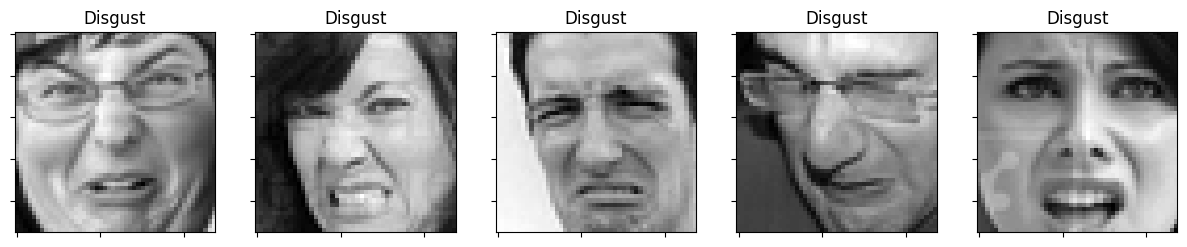

In [18]:
# DISGUST
plot_emotion(emotion_label=1)

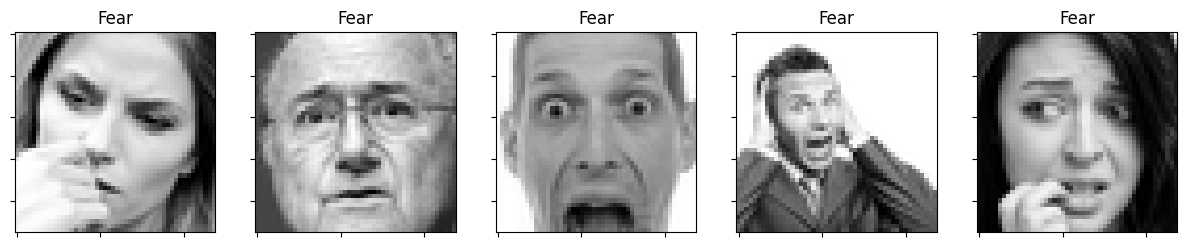

In [19]:
#FEAR
plot_emotion(emotion_label=2)

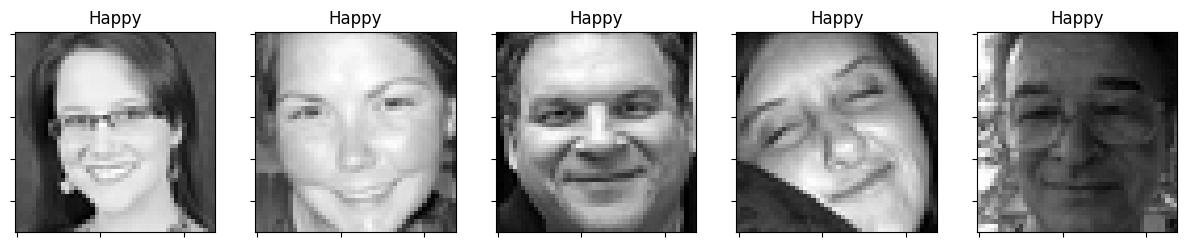

In [20]:
#HAPPY
plot_emotion(emotion_label=3)

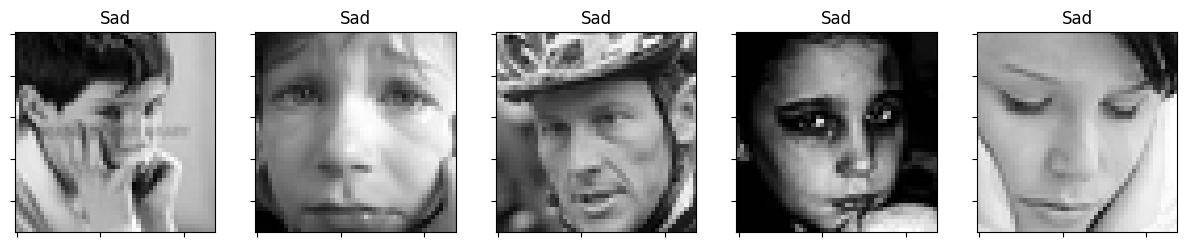

In [21]:
#SAD
plot_emotion(emotion_label=4)

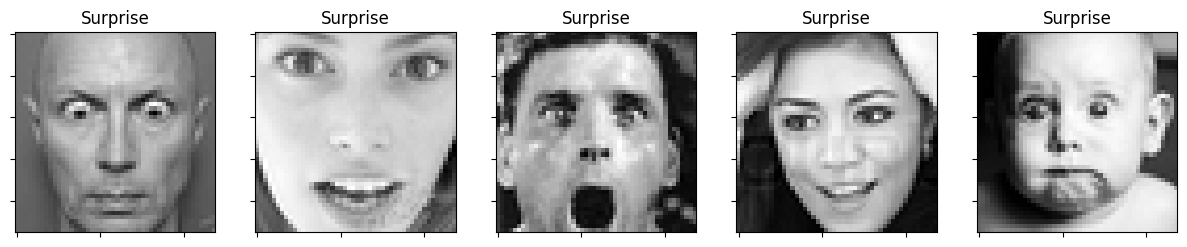

In [22]:
#SURPRISE
plot_emotion(emotion_label=5)

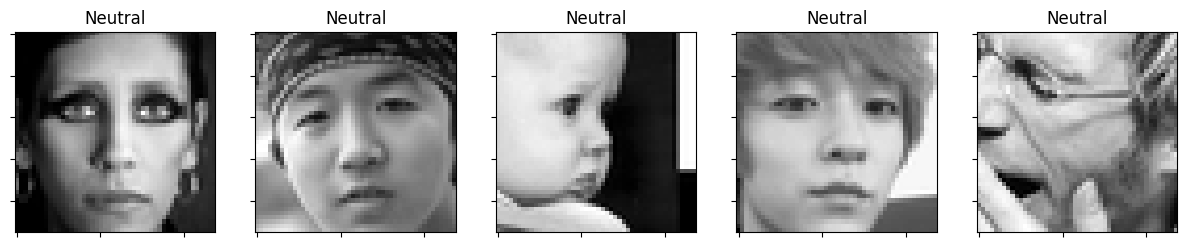

In [23]:
#NEUTRAL
plot_emotion(emotion_label=6)

In [24]:
# Compare and plot the distribution of emotion_labels in multiple datasets
# Parameters
# Arrays: A list of datasets with onehotcoded emotion labels
# Colors: A list of colors for the plots
# Titles: A list of titles for each dataset

In [25]:
import random
def plot_distributions(arrays, colors, titles):
  fig, axs=plt.subplots(1,len(arrays),figsize=(6*len(arrays),6),sharey=False)
  fig.subplots_adjust(hspace=.2,wspace=.2)
  axs=axs.ravel() # flatten
  x=emotions.values()
  for i,array in enumerate(arrays):  #
    df_array=pd.DataFrame()
    df_array["emotion"]=array.argmax(axis=1)
    y=df_array["emotion"].value_counts()
    keys_missed=list(set(emotions.keys()).difference(set(y.keys()))) # set allots unique value, so no emotion is repeated
    for key_missed in keys_missed:
      y[key_missed]=0  # initial key missed with 0(angry)
    axs[i].bar(x,y.sort_index(),color=colors[i])
    axs[i].set_title(titles[i])
    axs[i].grid()

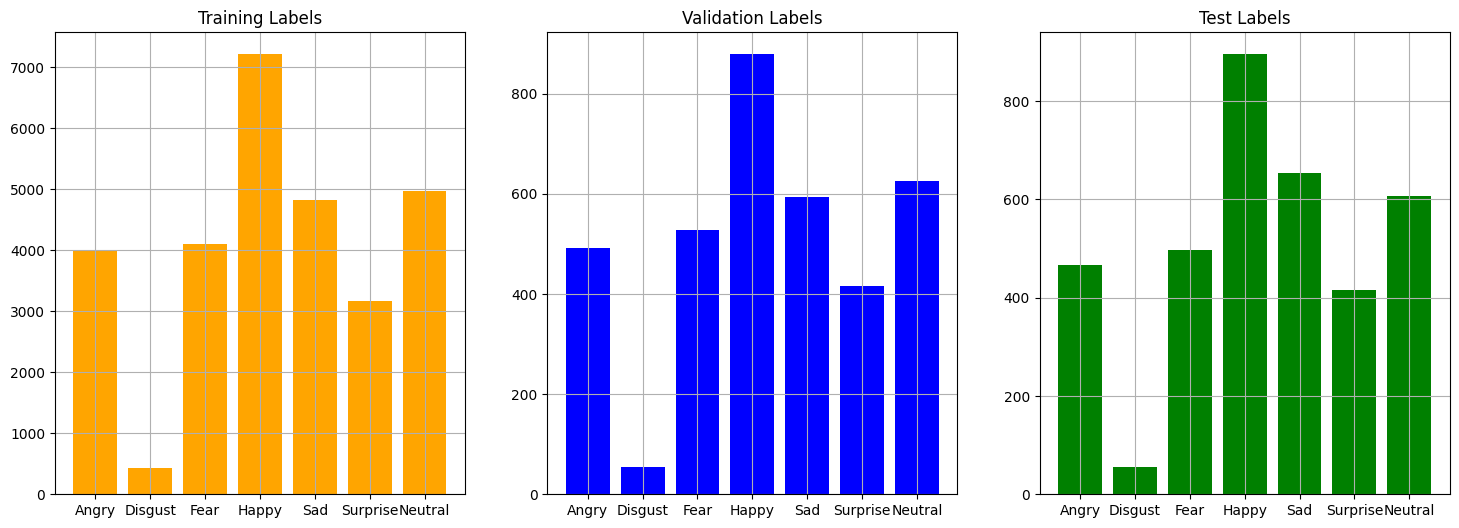

In [26]:
arrays=[train_labels,val_labels,test_labels]
colors=["orange","blue","green"]
titles=["Training Labels","Validation Labels","Test Labels"]
plot_distributions(arrays,colors,titles)
plt.show()

### Model Training

In [27]:
from keras import models
from keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPool2D

# Initialize a sequential model
model=models.Sequential()

# Add the first convolutional layer
model.add(Conv2D(32,(3,3),activation="relu",input_shape=(48,48,1)))  # activation function relu will take max. If negative, then 0, else postive number
# 32 * ((3*3)+1) 32*10=320  '+1' is the starting point of kernel or activaton point. Formula includes the starting point

# 48-3+1 = 46 in the output stage
# ((w-F)/S)+1   = ((48-3)/1)+1 = 45+1=46   (w is weight input size, F is filter size, S is stride)
# (23-3/1)+1=21 for output shape  (w is weight input size, F is filter size, S is stride)

# Add a max pooling layer to down sample the 3*3 to 2*2
model.add(MaxPool2D((2,2)))

# Add the second convolutional layer trying to get more complex input data from the figure using 64 filters
model.add(Conv2D(64,(3,3),activation="relu"))

# Kernel size 3,3 * input channels 32 + Bias term 1

# Add a max pooling layer to down sample the 3*3 to 2*2
model.add(MaxPool2D((2,2)))

# Add the third convolutional layer trying to get more complex input data from the figure using 64 filters
model.add(Conv2D(64,(3,3),activation="relu"))

# flatten the output from convolutoinal layers
model.add(Flatten())

# fully connected layer with Relu function
model.add(Dense(64,activation="relu"))
# Number of inputs from Flatten layer * number of neurons in the Dense + 64 bias term
# 8*8*64 number of inputs from flatten layer, comes out to 4096
# 4096 * 64 + 64 = 262208

# Adding the output from multi-class classification
model.add(Dense(7,activation="softmax"))
# number of inputs from Flatten layer * number of neurons in Dense + 7 bias layer
# 64 * 7 + 7 = 455






/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
# HW - youtube videos of how to create robot evolved. How robot works as a human
# HW - Semi supervised learning youtube video

In [31]:
from keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=1e-3),loss="categorical_crossentropy",metrics=["accuracy"])

In [32]:
model.summary()  # parameters running to get 7 emotions

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 318,407 (1.21 MB)

 Trainable params: 318,407 (1.21 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# train the model using training data, and validate with validation data
# model is trained for specific number of epochs or iterations
# class weights are used to handle imbalanced data set
history=model.fit(train_images,train_labels,epochs=12,validation_data=(val_images,val_labels),class_weight=class_weight,batch_size=64)



Epoch 1/12
449/449 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.3316 - loss: 0.2622 - val_accuracy: 0.4202 - val_loss: 1.5750
Epoch 2/12
449/449 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4615 - loss: 0.2182 - val_accuracy: 0.4798 - val_loss: 1.3937
Epoch 3/12
449/449 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5058 - loss: 0.2010 - val_accuracy: 0.5052 - val_loss: 1.3391
Epoch 4/12
449/449 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5381 - loss: 0.1896 - val_accuracy: 0.5177 - val_loss: 1.3395
Epoch 5/12
449/449 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5593 - loss: 0.1800 - val_accuracy: 0.5361 - val_loss: 1.2652
Epoch 6/12
449/449 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5860 - loss: 0.1699 - val_accuracy: 0.5405 - val_loss: 1.2391
Epoch 7/12
449/449 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6081 - loss: 0.1611 - val_accuracy: 0.5397 - val_loss: 1.2787
Epoch 8/12
449/449 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6287 - loss: 0.1523 - val_accuracy: 

### Model Evaluation

In [35]:
test_loss,test_accuracy=model.evaluate(test_images,test_labels)
# Predict the labels for test images
pred_test_labels=model.predict(test_images)
print("test_accuracy:",test_accuracy)
print("test_loss:",test_loss)

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5559 - loss: 1.3822
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
test_accuracy: 0.5558651685714722
test_loss: 1.382244348526001


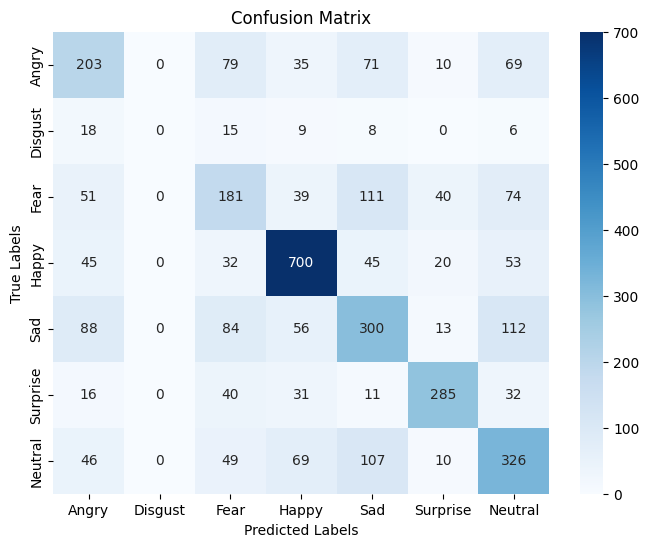

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# get true labels from test data set
true_labels=test_image_label

# get predicted labels from test data
predicted_labels=np.argmax(pred_test_labels,axis=1)
# creae the confusion matrix
matrix=confusion_matrix(true_labels,predicted_labels)
# defining emotion labels for visualization
emotion_labels=["Angry","Disgust","Fear","Happy","Sad","Surprise","Neutral"]
# Create a heat map
plt.figure(figsize=(8,6))
sns.heatmap(matrix,annot=True,cmap="Blues",fmt="d",xticklabels=emotion_labels,yticklabels=emotion_labels)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
# HW- study confusion matrix :: which 2 cross columns are inter-related

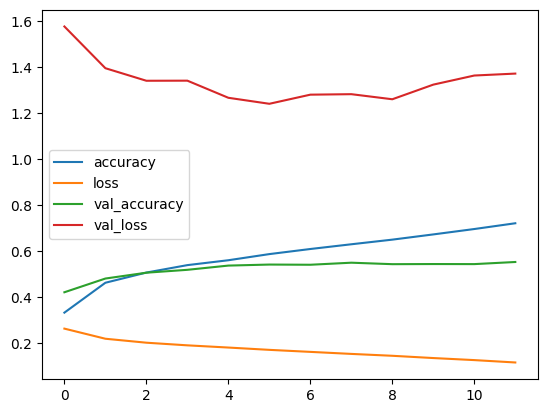

In [37]:
for key in history.history.keys():
  plt.plot(history.history[key],label=key)
plt.legend()
plt.show()

In [38]:
# Model prediction
def plot_image_and_emotion(test_image_array, test_image_label, pred_test_labels, image_number):

    # Create a figure with two subplots
    fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=False)

    # Define the labels for the bar chart
    bar_label = emotions.values()

    # Plot the test image in the left subplot
    axs[0].imshow(test_image_array[image_number], 'gray')
    axs[0].set_title(emotions[test_image_label[image_number]])

    # Plot the predicted emotion labels as a bar chart in the right subplot
    axs[1].bar(bar_label, pred_test_labels[image_number], color='orange', alpha=0.7)
    #The `alpha` parameter sets the transparency of the bars in the bar chart. A value of 0.7 makes the bars slightly transparent, allowing any underlying grid lines to be visible.
    axs[1].grid()

    # Show the figure
    plt.show()

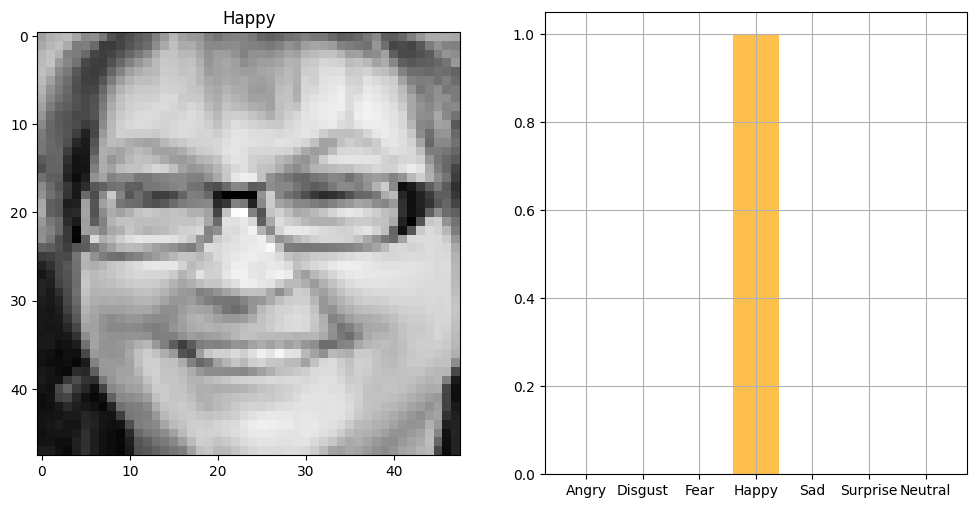

In [40]:
# Show the figure
# Plot and compare the true emotion label and predicted emotion labels for the 100th test image
plot_image_and_emotion(test_image_array, test_image_label, pred_test_labels, 100)



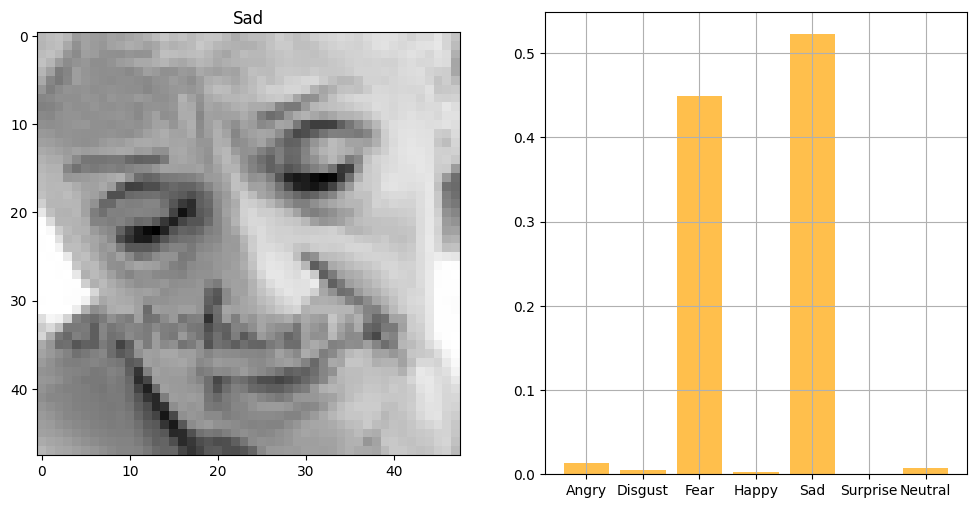

In [41]:
# Plot and compare the true emotion label and predicted emotion labels for the 600th test image
plot_image_and_emotion(test_image_array, test_image_label, pred_test_labels, 600)


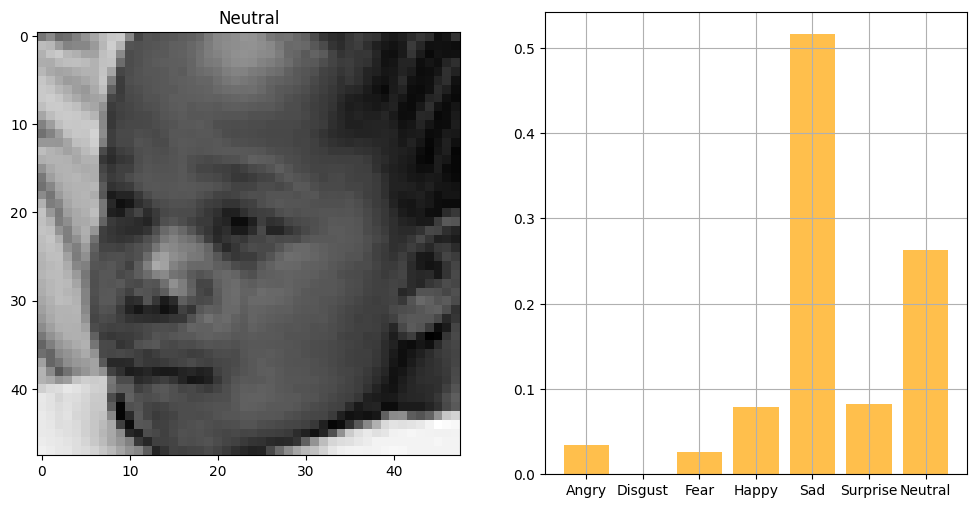

In [43]:
# Plot and compare the true emotion label and predicted emotion labels for the 1200th test image
plot_image_and_emotion(test_image_array, test_image_label, pred_test_labels, 900)